# XGBoost v5 (Two-Stage Model)

This notebook builds on v4 by:

1. Splitting into two binary models instead of one multiclass model
2. Model A: just cancelled vs not cancelled: scale_pos_weight works properly now since it's binary
3. Model B: just delayed vs on_time, on non-cancelled flights only (uses class weights)

v4 showed that scale_pos_weight destroys delayed recall when you use it on a multiclass problem. The two-stage approach fixes that by letting each model focus on one thing. Model A doesn't have to worry about delays and Model B doesn't have to worry about cancellations.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
import sys
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             average_precision_score)
from xgboost import XGBClassifier

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Data

Same dataset as v3 and v4, just splitting it differently for the two models.

In [3]:
sys.path.append('../../../4_scripts')
from flight_weather_setup import load_data, get_splits

df = load_data()
(X_train_a, y_train_a, X_val_a, y_val_a, X_test_a, y_test_a,
 X_train_b, y_train_b, X_val_b, y_val_b, X_test_b, y_test_b,
 y_val_true, y_test_true, features) = get_splits(df)

if len(X_train_a) > 2_000_000:
    idx = np.random.choice(len(X_train_a), 2_000_000, replace=False)
    X_train_a = X_train_a.iloc[idx]
    y_train_a = y_train_a.iloc[idx]

neg = (y_train_a == 0).sum()
pos = (y_train_a == 1).sum()
scale_pw = round(neg / pos)
print(f'scale_pos_weight = {neg:,} / {pos:,} = {scale_pw}')
print(f'Model A -- train: {X_train_a.shape}, val: {X_val_a.shape}')
print(f'Model B -- train: {X_train_b.shape}, val: {X_val_b.shape}')

scale_pos_weight = 1,964,968 / 35,032 = 56
Model A -- train: (2000000, 18), val: (6310951, 18)
Model B -- train: (13535123, 18), val: (6199937, 18)


## Model A: Cancellation Prediction

Binary now so scale_pos_weight actually does what we want. In v4 it was trying to balance three classes at once, here it just needs to find cancellations. Each cancelled flight counts as about 50 normal flights during training.

In [4]:
model_a = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    scale_pos_weight=scale_pw,  # this is the key difference from v4
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_a.fit(X_train_a, y_train_a,
            eval_set=[(X_val_a, y_val_a)],
            verbose=False)
print('model A done')

model A done


Model A val PR-AUC: 0.0563
               precision    recall  f1-score   support

not_cancelled       0.99      0.80      0.89   6199937
    cancelled       0.04      0.42      0.07    111014

     accuracy                           0.80   6310951
    macro avg       0.51      0.61      0.48   6310951
 weighted avg       0.97      0.80      0.87   6310951



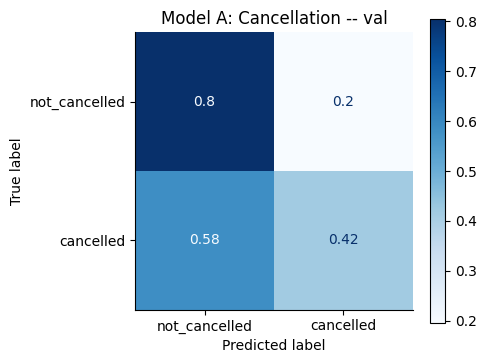

In [5]:
# check cancelled recall -- this is what we care about most for model A
pred_a_val = model_a.predict(X_val_a)
prauc_a = average_precision_score(y_val_a, model_a.predict_proba(X_val_a)[:, 1])

print(f'Model A val PR-AUC: {prauc_a:.4f}')
print(classification_report(y_val_a, pred_a_val,
      target_names=['not_cancelled', 'cancelled'], zero_division=0))

cm_a = confusion_matrix(y_val_a, pred_a_val)
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)
fig_a, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_a_norm, display_labels=['not_cancelled', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model A: Cancellation -- val')
plt.tight_layout()
plt.show()

## Model B: Delay Prediction

Non-cancelled flights only. Much simpler problem now, just on_time vs delayed. Using class weights same as v3.

In [6]:
weights_b = compute_sample_weight('balanced', y_train_b)

model_b = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model_b.fit(X_train_b, y_train_b,
            sample_weight=weights_b,
            eval_set=[(X_val_b, y_val_b)],
            verbose=False)
print('model B done')

model B done


              precision    recall  f1-score   support

     on_time       0.89      0.66      0.76   5127027
     delayed       0.27      0.60      0.37   1072910

    accuracy                           0.65   6199937
   macro avg       0.58      0.63      0.57   6199937
weighted avg       0.78      0.65      0.69   6199937



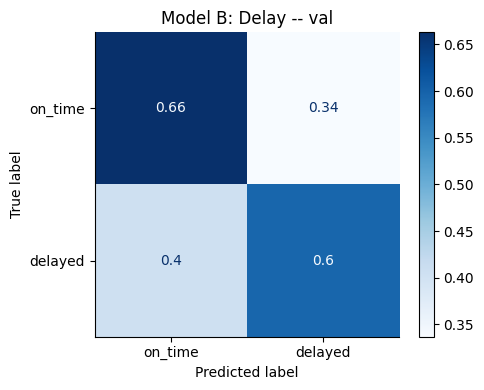

In [7]:
pred_b_val = model_b.predict(X_val_b)
print(classification_report(y_val_b, pred_b_val,
      target_names=['on_time', 'delayed'], zero_division=0))

cm_b = confusion_matrix(y_val_b, pred_b_val)
cm_b_norm = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True)
fig_b, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_b_norm, display_labels=['on_time', 'delayed']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model B: Delay -- val')
plt.tight_layout()
plt.show()

## Putting It Together (**Cascade**)

Model A goes first. If it flags a flight as cancelled, we're done. Otherwise Model B decides between on_time and delayed.

val cascade macro F1: 0.3624
              precision    recall  f1-score   support

     on_time       0.88      0.59      0.71   5127027
     delayed       0.26      0.39      0.31   1072910
   cancelled       0.04      0.42      0.07    111014

    accuracy                           0.55   6310951
   macro avg       0.39      0.47      0.36   6310951
weighted avg       0.76      0.55      0.63   6310951



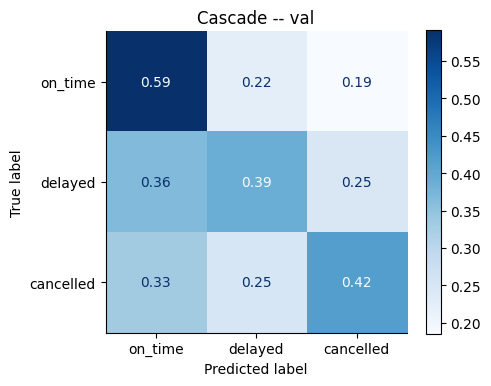

In [8]:
def cascade_predict(X, model_a, model_b, thresh_a=0.5, thresh_b=0.5):
    cancelled = model_a.predict_proba(X)[:, 1] >= thresh_a
    delayed   = model_b.predict_proba(X)[:, 1] >= thresh_b
    return np.where(cancelled, 2, np.where(delayed, 1, 0))

y_val_pred = cascade_predict(X_val_a, model_a, model_b)
mf1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'val cascade macro F1: {mf1_val:.4f}')
print(classification_report(y_val_true, y_val_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_val = confusion_matrix(y_val_true, y_val_pred)
cm_val_norm = cm_val.astype(float) / cm_val.sum(axis=1, keepdims=True)
fig_val, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_val_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade -- val')
plt.tight_layout()
plt.show()

## Test Set Results

test cascade macro F1: 0.3582
              precision    recall  f1-score   support

     on_time       0.84      0.51      0.64   3091391
     delayed       0.31      0.38      0.34    863057
   cancelled       0.05      0.49      0.10    123191

    accuracy                           0.48   4077639
   macro avg       0.40      0.46      0.36   4077639
weighted avg       0.70      0.48      0.56   4077639



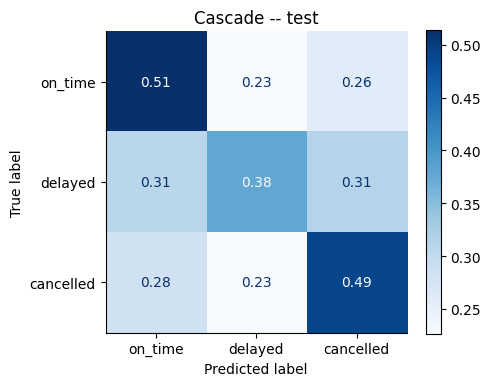

In [9]:
y_test_pred = cascade_predict(X_test_a, model_a, model_b)
mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'test cascade macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

cm_test = confusion_matrix(y_test_true, y_test_pred)
cm_test_norm = cm_test.astype(float) / cm_test.sum(axis=1, keepdims=True)
fig_test, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_test_norm, display_labels=['on_time', 'delayed', 'cancelled']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Cascade -- test')
plt.tight_layout()
plt.show()

## v1 through v5 Comparison

Does splitting into two models actually do better than a single model with weights?

               model  val macro F1  test macro F1
     v1 flights only        0.3054         0.2954
         v2 +weather        0.3641         0.3594
         v3 +weights        0.3750         0.3770
v4 +scale_pos_weight        0.2795         0.2614
     v5 cascade +spw        0.3624         0.3582


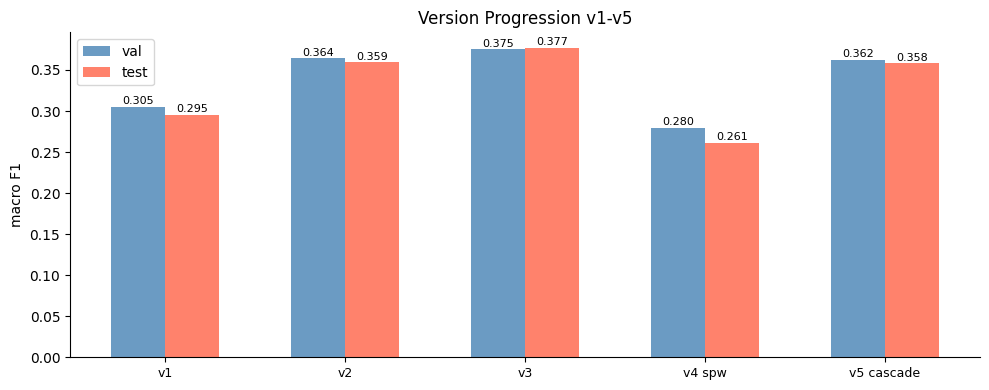

In [10]:
v1_val,  v1_test  = 0.3054, 0.2954
v2_val,  v2_test  = 0.3641, 0.3594
v3_val,  v3_test  = 0.3750, 0.3770
v4_val,  v4_test  = 0.2795, 0.2614

comparison = pd.DataFrame({
    'model':         ['v1 flights only', 'v2 +weather', 'v3 +weights',
                      'v4 +scale_pos_weight', 'v5 cascade +spw'],
    'val macro F1':  [v1_val, v2_val, v3_val, v4_val, round(mf1_val,  4)],
    'test macro F1': [v1_test, v2_test, v3_test, v4_test, round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

fig_comp, ax = plt.subplots(figsize=(10, 4))
x = np.arange(5)
width = 0.3
vals  = [v1_val, v2_val, v3_val, v4_val, mf1_val]
tests = [v1_test, v2_test, v3_test, v4_test, mf1_test]
ax.bar(x - width/2, vals,  width, label='val',  color='steelblue', alpha=0.8)
ax.bar(x + width/2, tests, width, label='test', color='tomato',    alpha=0.8)
for i, (v, t) in enumerate(zip(vals, tests)):
    ax.text(i - width/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, t + 0.003, f'{t:.3f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['v1', 'v2', 'v3', 'v4 spw', 'v5 cascade'], fontsize=9)
ax.set_ylabel('macro F1')
ax.set_title('Version Progression v1-v5')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Cancelled recall jumped to 42-49% which is the best we've gotten so far. But precision is only 4-5% meaning it's still flagging a ton of false cancellations. Overall F1 is still a bit below v3.

The scale_pos_weight of 56 is probably just too aggressive. In v6 we'll add SMOTE to generate better synthetic cancellation examples and lower the weight so the model doesn't overcorrect as hard.